In [1]:
### Deconvolution
from csbdeep.models import CARE
from csbdeep.utils import normalize

### Segmentation
from cellpose_omni import models
from omnipose.utils import normalize99

### Measurement
from MEDUSSA.measure import SizeDataFrame
from MEDUSSA.transform import ParamSampler
from MEDUSSA.utils import CellColorer

### Plotting
from matplotlib import pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

### Visualization
from skimage import io
from skimage.color import label2rgb

### Other
import numpy as np
import pandas as pd
from skimage.measure import regionprops_table

### Read the image 
fm_image = io.imread('https://github.com/OReyesMatte/MEDUSSA/raw/refs/heads/main/BsubtilismVenus_026_FM.tif')


/Users/reyesmatte/miniforge3/envs/medussa/lib/python3.10/site-packages/omnipose/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/Users/reyesmatte/miniforge3/envs/medussa/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2025-10-20 11:51:12,845 [INFO] No OpenGL_accelerate module loaded: No module named 'OpenGL_accelerate'
2025-10-20 11:51:16,180 [INFO] arviz_base not installed
2025-10-20 11:51:16,181 [INFO] arviz_stats not installed
2025-10-20 11:51:16,181 [INFO] arviz_plots not installed


In [2]:
### Download the deconvolution model
!wget https://github.com/OReyesMatte/MEDUSSA/raw/refs/heads/main/CARE/FM2FM.zip
!unzip FM2FM.zip -d CARE_models

--2025-10-20 11:51:31--  https://github.com/OReyesMatte/MEDUSSA/raw/refs/heads/main/CARE/FM2FM.zip
Resolving github.com (github.com)... 140.82.121.4
Connecting to github.com (github.com)|140.82.121.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/OReyesMatte/MEDUSSA/refs/heads/main/CARE/FM2FM.zip [following]
--2025-10-20 11:51:32--  https://raw.githubusercontent.com/OReyesMatte/MEDUSSA/refs/heads/main/CARE/FM2FM.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3718947 (3,5M) [application/zip]
Saving to: ‘FM2FM.zip’

FM2FM.zip           100%[===================>]   3,55M  19,2MB/s    in 0,2s    

2025-10-20 11:51:33 (19,2 MB/s) - ‘FM2FM.zip’ saved [3718947/3718947]

Archive:  FM2FM.zip
   cr

In [3]:
### Load the deconvolution model

model_dir = 'CARE_models/'
model_2D = CARE(config=None, name='CARE_FM2FM', basedir=model_dir)

### Predict deconvolved image
fm_deconvolution = model_2D.predict(normalize(fm_image),axes='YX',n_tiles=(4,4))

Loading network weights from 'weights_best.h5'.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:03<00:00,  5.11it/s]


In [4]:
### Download the segmentation model
!wget https://github.com/OReyesMatte/MEDUSSA/raw/refs/heads/main/Omnipose/FMSeg.zip
!unzip FMSeg.zip -d Omnipose_models

--2025-10-20 11:51:41--  https://github.com/OReyesMatte/MEDUSSA/raw/refs/heads/main/Omnipose/FMSeg.zip
Resolving github.com (github.com)... 140.82.121.4
Connecting to github.com (github.com)|140.82.121.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/OReyesMatte/MEDUSSA/refs/heads/main/Omnipose/FMSeg.zip [following]
--2025-10-20 11:51:41--  https://raw.githubusercontent.com/OReyesMatte/MEDUSSA/refs/heads/main/Omnipose/FMSeg.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 24986663 (24M) [application/zip]
Saving to: ‘FMSeg.zip’

FMSeg.zip           100%[===================>]  23,83M  26,8MB/s    in 0,9s    

2025-10-20 11:51:43 (26,8 MB/s) - ‘FMSeg.zip’ saved [24986663/24986663]

Archive:  F

In [5]:
### Load the segmentation model and specify model parameters
params = {'rescale': None, # upscale or downscale your images, None = no rescaling 

          'mask_threshold': 0, # erode or dilate masks with higher or lower values 

          'flow_threshold': 0.4, # default is .4, but only needed if there are spurious masks to clean up; slows down output

          'transparency': True, # transparency in flow output

          'omni': True, # we can turn off Omnipose mask reconstruction, not advised 

          'cluster': True, # use DBSCAN clustering

          'resample': True, # whether or not to run dynamics on rescaled grid or original grid 

          # 'verbose': False, # turn on if you want to see more output 

          'tile': False, # average the outputs from flipped (augmented) images; slower, usually not needed 

          'niter': None, # None lets Omnipose calculate # of Euler iterations (usually <20) but you can tune it for over/under segmentation 

          'augment': False, # Can optionally rotate the image and average outputs, usually not needed 

          'affinity_seg': False, # new feature, stay tuned...

         }

model_path = 'Omnipose_models/FMSeg'
model = models.CellposeModel(pretrained_model=model_path, nclasses=3, nchan=1, gpu=False, diam_mean=0)

masks, flows, styles = model.eval(normalize99(fm_deconvolution),**params)

2025-10-20 11:51:51,209 [INFO] >>>> using CPU
2025-10-20 11:51:51,212 [INFO] WARNING: MKL version on torch not working/installed - CPU version will be slightly slower.
2025-10-20 11:51:51,213 [INFO] see https://pytorch.org/docs/stable/backends.html?highlight=mkl


In [6]:
### Measure

measurements = SizeDataFrame([masks],from_files=False)
measurements.insert(0,'Experiment','Test')
metrics = measurements.columns[2:]

### Transform
df_posteriors = pd.read_csv('https://raw.githubusercontent.com/OReyesMatte/MEDUSSA/refs/heads/main/Figures/FigureS4/posterior_segmentation_measurements.csv')

transformed_measurements = ParamSampler(data_df=measurements,posterior_df=df_posteriors,columns=['Experiment'],metrics=metrics)
labels = regionprops_table(label_image=masks,properties=['label'])['label']
transformed_measurements.insert(1,'Label',labels)

masks_by_width = CellColorer(masks,labels,np.array(transformed_measurements['Width_mu']))
masks_by_length = CellColorer(masks,labels,np.array(transformed_measurements['Length_mu']))

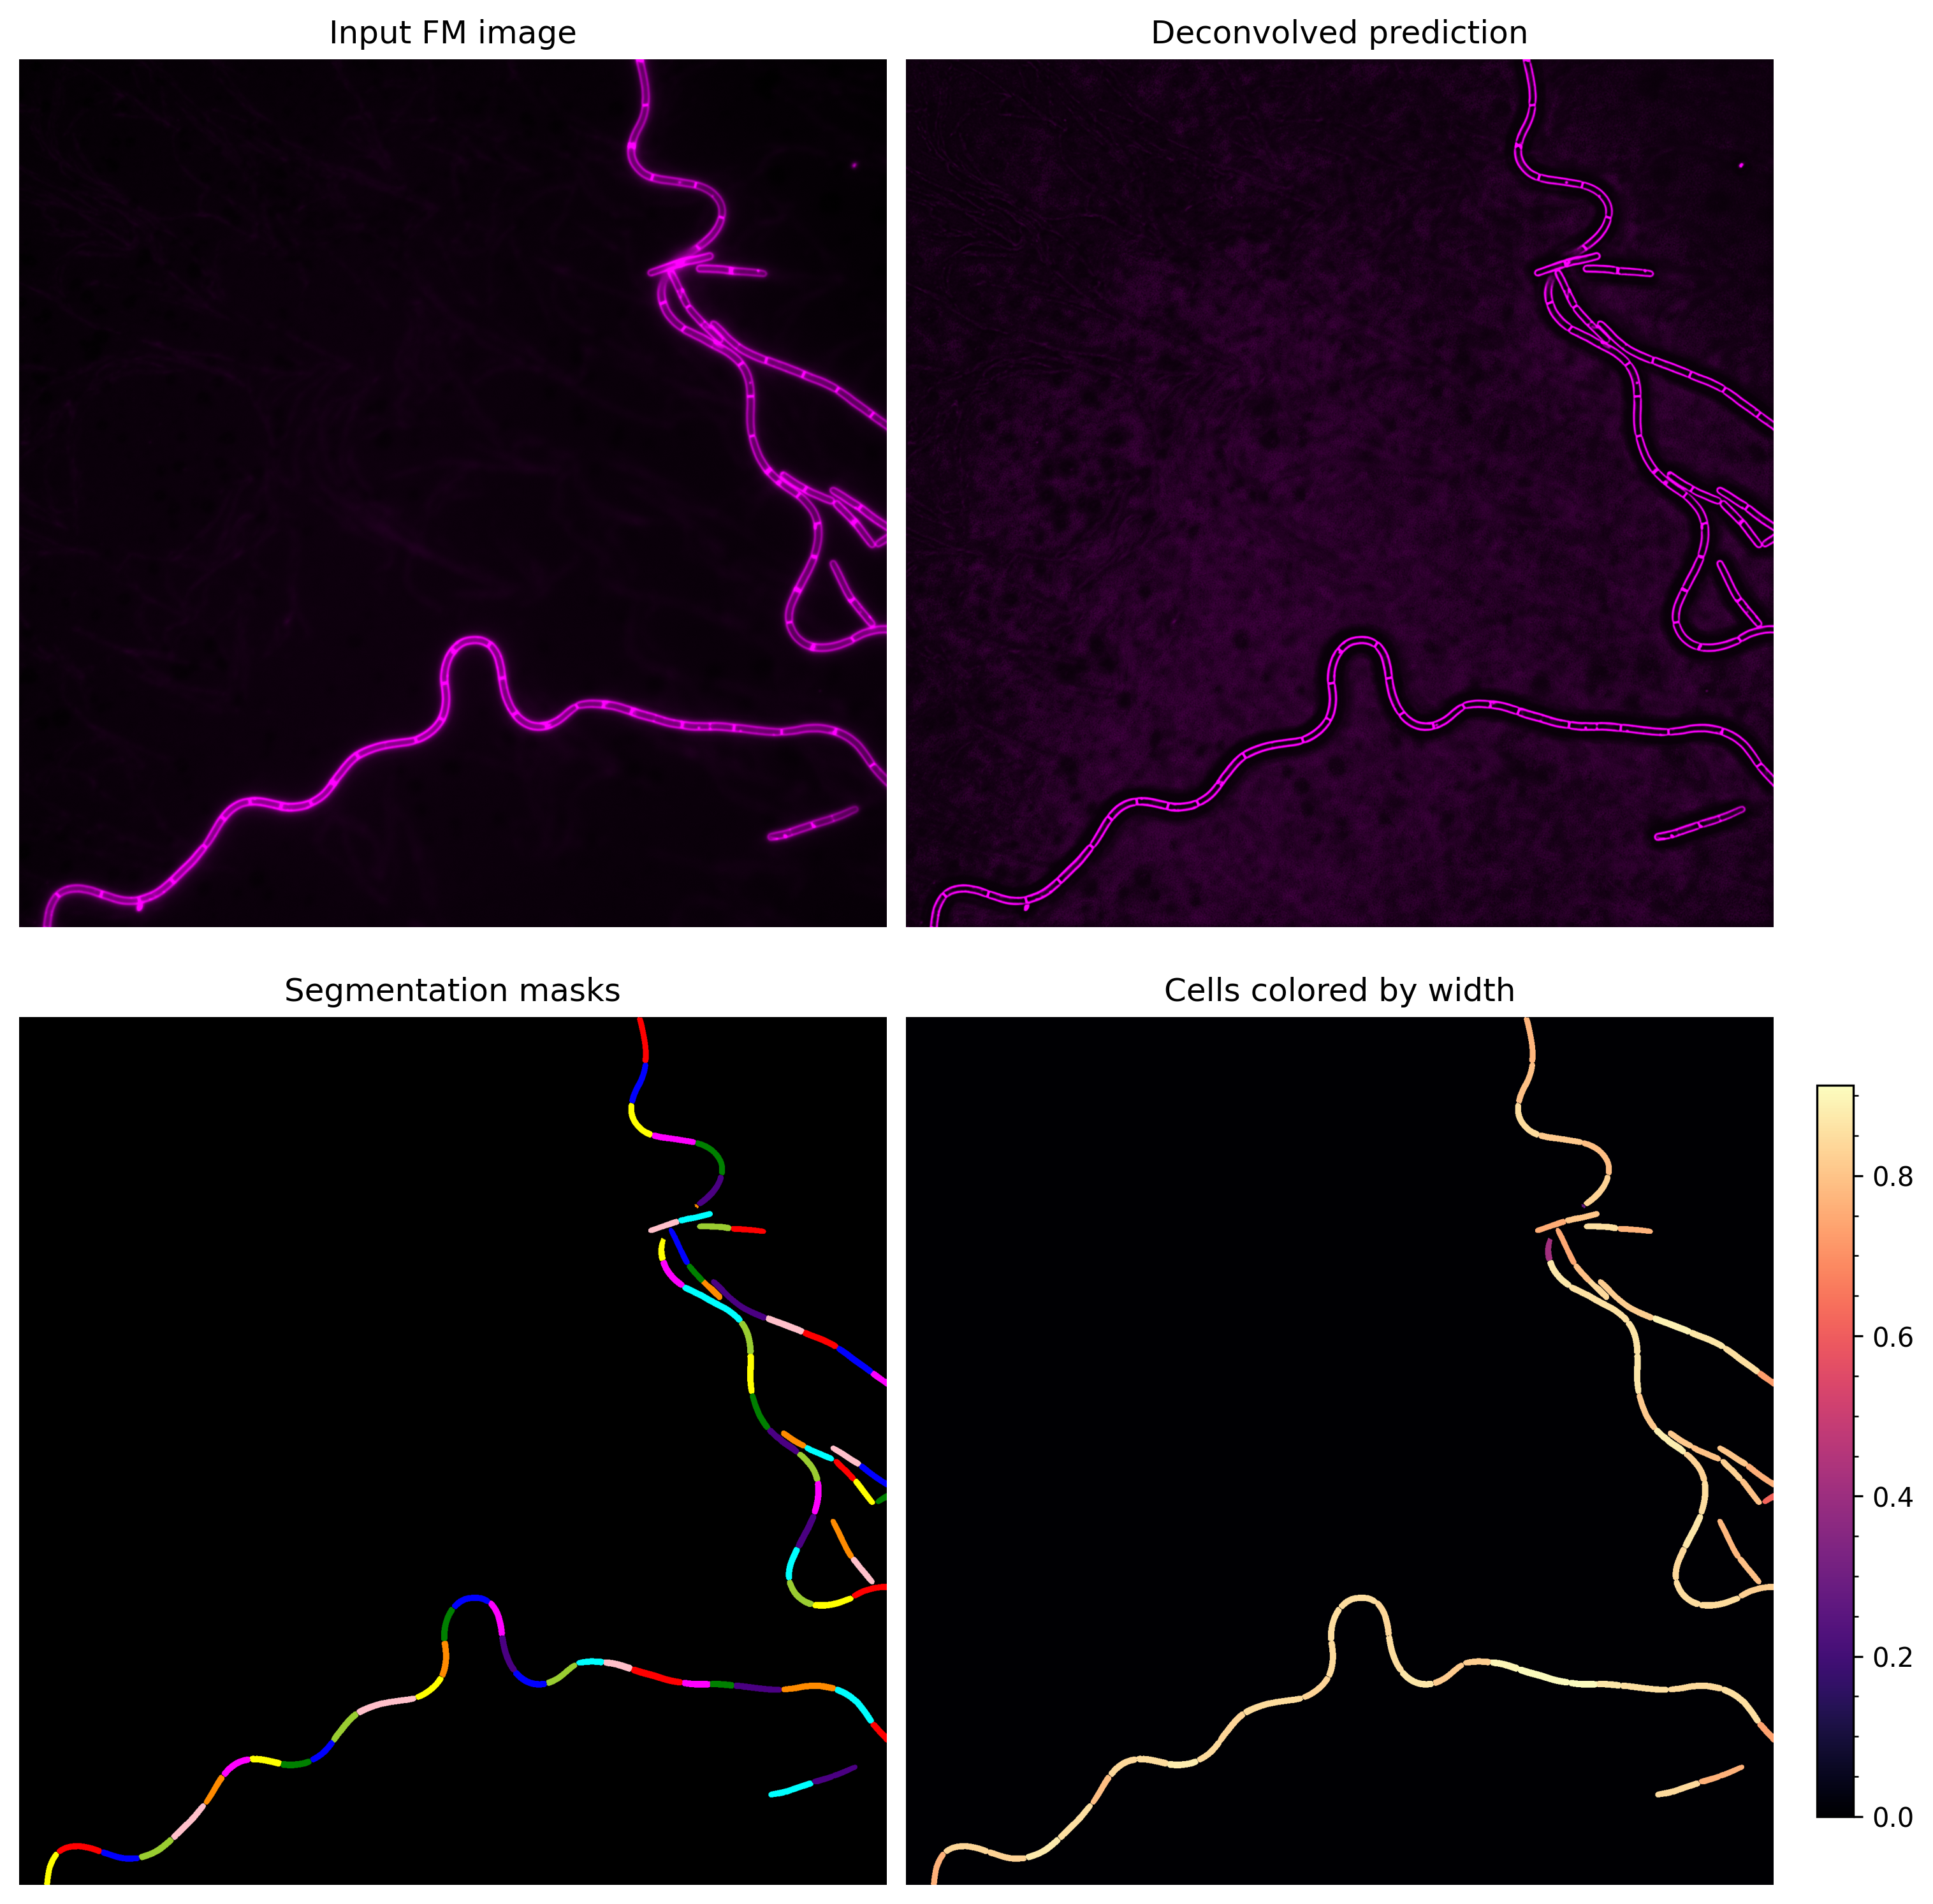

In [7]:
## Assemble!
cmap = LinearSegmentedColormap.from_list('magenta',[(0, 0, 0), (1, 0, 1)],N=256)
fig,ax = plt.subplots(dpi=300,figsize=(10,10),ncols=2,nrows=2,layout='constrained')

ax[0,0].imshow(normalize(fm_image),cmap=cmap,vmax=1)
ax[0,0].axis('off')
ax[0,0].set_title('Input FM image')

ax[0,1].imshow(normalize(fm_deconvolution),cmap=cmap,vmax=0.7)
ax[0,1].axis('off')
ax[0,1].set_title('Deconvolved prediction')

ax[1,0].imshow(label2rgb(masks))
ax[1,0].axis('off')
ax[1,0].set_title('Segmentation masks')

pos = ax[1,1].imshow(masks_by_width,cmap='magma')#,vmin=0.5,vmax=1)
ax[1,1].set_title('Cells colored by width')
ax[1,1].axis('off')
cbar = fig.colorbar(pos,shrink=0.8)
cbar.minorticks_on()

fig.savefig('MEDUSSA_example.png')